# 鐵達尼號乘客資料
資料下載網址：https://raw.githubusercontent.com/Code-Gym/python-dataset/master/titanic.csv 
# 欄位解釋
PassengerId:乘客ID, Survived:是否生存(1是0否), Pclass:船艙等級(1-3), Sex:性別, Age:年齡, SibSp:在船上同為兄弟姐妹或配偶的數目,
Parch:在船上同為家族的父母及小孩的數目, Ticket:船票票號, Fare:乘客票價, Cabin:乘客居住艙號, Embarked:搭船的港口

In [16]:
import pandas as pd
import numpy  as np
url = 'C:/Users/Administrator/Documents/附件/python/titanic.xlsx'
df  = pd.read_excel(url)
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# 年紀平均值(男女區分)

In [18]:
# 查看缺失值,age有177個,下面分別以各性別平均值做補值(避免影響平均年齡)
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [19]:
# sex 儲存各性別平均值
sex_age = df.groupby('Sex').Age.mean()
sex_age

Sex
female    27.915709
male      30.726645
Name: Age, dtype: float64

In [20]:
# 製作補年紀平均值函數
def fix_age(x,y):
    if   (x == 'female') & (str(y) == 'nan'):
        age = int(sex_age[0])
    elif (x == 'male') & (str(y) =='nan'):
        age = int(sex_age[1])
    else:
        age = y
    return age

In [39]:
df.head(6)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,30.0,0,0,330877,8.4583,NaN,Q


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# 圖表

In [24]:
male_all   = df[df['Sex'] == 'male'].Sex.count()
female_all = df[df['Sex'] == 'female'].Sex.count()
male_s     = df[(df['Sex'] == 'male') & df['Survived'] == 1].Sex.count()
female_s   = df[(df['Sex'] == 'female') & df['Survived'] == 1].Sex.count()

In [25]:
df_sex = pd.DataFrame(data = {'sex_all':[male_all, female_all], 'sex_s':[male_s, female_s]}, index = ['male', 'female'])
df_sex

,sex_all,sex_s
male,577,109
female,314,233


# 由此圓餅圖可以得知雖然搭乘男性比例大於女性, 但最後存活是女性大於男性
可能原因為當初逃生艇位置有限,優先讓女性搭乘

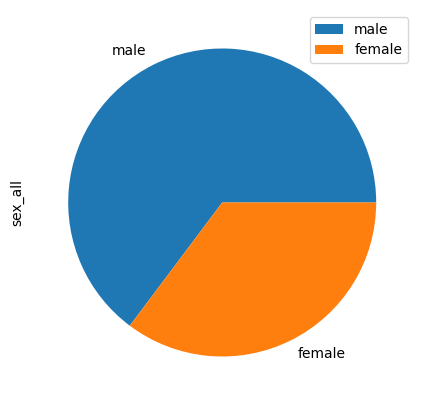

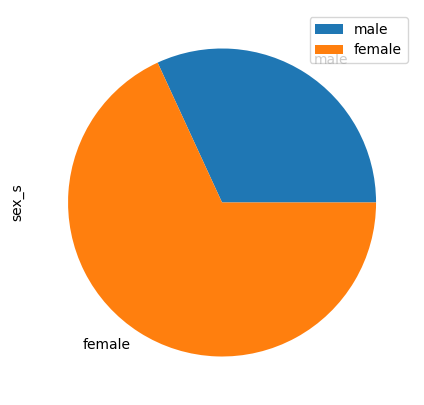

In [26]:
plot_all = df_sex.plot.pie(y = 'sex_all', figsize = (5,5))
plot_s = df_sex.plot.pie(y = 'sex_s', figsize = (5,5))